# Strategy: Boundary Conditioning (`add_bounds`) for Patch-Based Consistency Models

## Problem

When generating fields over a large domain by assembling independent patches, **discontinuities appear at patch seams**.  
Each patch is estimated without knowing what its neighbours predicted, so the model has no incentive to match at the edges.

## Idea (from the diffusion notebook `diffusion_srnn_wpreproc_add_bound.ipynb`)

Introduce the **boundary of a patch** — the outer overlap ring, derived from `patch_size - stride` — as **additional conditioning** for the UNet, alongside observations and ERA5 covariates.

```
boundary = patch values where mask_boundary == 1   (the ring)
         = 0 everywhere inside the ring
```

- **Training**: the boundary is extracted from the **ground-truth target** of the same sample (self-supervised, no leakage because the center is zeroed out).
- **Inference**: patches are processed **sequentially in raster order**; the boundary of a patch is built from the already-computed predictions of its **left** and **top** neighbours (right/bottom are not yet available).

## Design principles

| Principle | Choice |
|---|---|
| Optional | `add_bounds: bool = False` everywhere — default behaviour unchanged |
| Boundary mask | Explicit binary tensor `mask_boundary (H, W)` — 1 in the ring, 0 in the centre |
| UNet interface | Extra channels concatenated to the input: `cat([x_noisy, y_obs, mask_obs, bound, mask_bound])` |
| Inference order | Row-major (top→bottom, left→right); extensible to other orders |
| Multi-GPU | Sequential inference always runs on rank 0 after `all_gather` |

---

**Files to modify** (each change is optional/guarded by `add_bounds`):

| File | Change |
|---|---|
| `consistency_solver.py` — `ConsistencyUNetConfig` | Add `add_bounds`, `n_bound_channels` |
| `consistency_solver.py` — `ConsistencyUNet.__init__` | Extend `total_input_channels` by `2 * n_bound_channels` |
| `consistency_solver.py` — `ConsistencyUNet.forward` | Accept `boundaries`, `mask_bound` kwargs |
| `consistency_solver.py` — `ConsistencyUNetSolver.forward` | Sequential loop + boundary cache when `add_bounds` |
| `models_consistency.py` — `base_step` | Build boundary from `sbatch.tgt` at train time |
| `models_consistency.py` — `test_step` | Pass `boundary_buffer` and trigger sequential inference |

---
## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Optional, Dict, Tuple

# ── Global config (mirrors YAML values) ───────────────────────────────────────
PATCH_H, PATCH_W = 256, 256       # patch_dims yc / xc
STRIDE_H, STRIDE_W = 200, 200     # strides_test yc / xc

# The overlap ring = patch - stride on each side  → border width in pixels
BORDER_H = (PATCH_H - STRIDE_H) // 2   # 28 px top/bottom ring
BORDER_W = (PATCH_W - STRIDE_W) // 2   # 28 px left/right ring

N_TIME        = 8        # time_steps for patch_x10
N_TGT_VARS    = 1        # e.g. SIT only
N_OBS_VARS    = 7        # sat vars + covariates  (computed.input_vars_all)
C_OUT         = N_TGT_VARS * N_TIME   # output channels of UNet
C_IN          = N_OBS_VARS * N_TIME   # observation channels

ADD_BOUNDS    = True     # ← the option we are designing

print(f"Patch:   ({PATCH_H}, {PATCH_W})")
print(f"Stride:  ({STRIDE_H}, {STRIDE_W})")
print(f"Border:  ({BORDER_H}, {BORDER_W})  pixels on each side")
print(f"C_OUT = {C_OUT},  C_IN = {C_IN}")
print(f"add_bounds = {ADD_BOUNDS}")

Patch:   (256, 256)
Stride:  (200, 200)
Border:  (28, 28)  pixels on each side
C_OUT = 8,  C_IN = 56
add_bounds = True


---
## 2. Boundary Mask Definition

The boundary mask is a **binary (H, W) tensor** that is 1 in the overlap ring and 0 in the centre.  
Its shape matches one spatial patch; it is broadcast over `(B, C, H, W)` at runtime.

The ring width equals `(patch_size - stride) // 2` — i.e. exactly the overlap between two adjacent patches.

**Important**: the mask is **not** NaN-aware yet — it only encodes *geometry*.  
The actual availability of boundary data (NaN in the neighbour's prediction) is handled separately in `extract_boundary`.

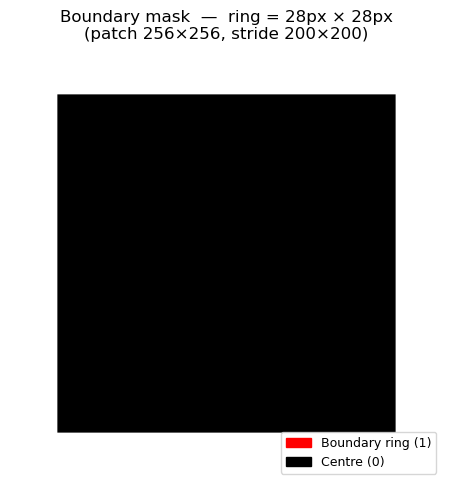

Ring pixels: 25536 / 65536  (39.0 %)


In [4]:
def make_boundary_mask(patch_h: int, patch_w: int,
                       border_h: int, border_w: int) -> torch.Tensor:
    """Return a binary (H, W) mask: 1 in the overlap ring, 0 in the centre.

    Args:
        patch_h, patch_w : spatial size of one patch
        border_h, border_w: ring width derived from (patch - stride) // 2
    Returns:
        mask (H, W) float32, values in {0., 1.}
    """
    mask = torch.ones(patch_h, patch_w, dtype=torch.float32)
    # Zero out the centre (everything inside the ring)
    mask[border_h : patch_h - border_h,
         border_w : patch_w - border_w] = 0.
    return mask


mask_boundary = make_boundary_mask(PATCH_H, PATCH_W, BORDER_H, BORDER_W)

# ── Visualize ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(mask_boundary, cmap="gray", vmin=0, vmax=1)
ax.set_title(f"Boundary mask  —  ring = {BORDER_H}px × {BORDER_W}px\n"
             f"(patch {PATCH_H}×{PATCH_W}, stride {STRIDE_H}×{STRIDE_W})")
ax.axis("off")
ring_patch = mpatches.Patch(color="red", label="Boundary ring (1)")
center_patch = mpatches.Patch(color="black", label="Centre (0)")
ax.legend(handles=[ring_patch, center_patch], loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()
print(f"Ring pixels: {int(mask_boundary.sum())} / {PATCH_H * PATCH_W}  "
      f"({100 * mask_boundary.mean():.1f} %)")

---
## 3. Boundary Extraction Utilities

Two functions:
1. `extract_boundary(patch, mask)` — keep only the ring of a patch (zero or NaN elsewhere)
2. `build_boundary_conditioning(neighbor_cache, iy, ix, mask)` — assemble available left/top neighbours into a boundary tensor for the current patch `(iy, ix)`

### Neighbour overlap geometry

```
Left neighbour (iy, ix-1):  its right  border_w columns → our left  border_w columns
Top  neighbour (iy-1, ix):  its bottom border_h rows    → our top   border_h rows
```

When a neighbour is not yet computed, its contribution is **zero** and `mask_bound` is **zero** there too.

In [5]:
def extract_boundary(patch: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Keep only the ring values; zero everywhere else.

    Args:
        patch : (C, H, W)  — any prediction or GT tensor
        mask  : (H, W)     — 1 in the ring, 0 in the centre
    Returns:
        boundary : (C, H, W) — patch * mask, NaN replaced by 0
    """
    boundary = torch.nan_to_num(patch) * mask.unsqueeze(0)
    return boundary


def build_boundary_conditioning(
    neighbor_cache: Dict[Tuple[int, int], torch.Tensor],
    iy: int, ix: int,
    mask: torch.Tensor,
    border_h: int, border_w: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Assemble the boundary tensor for patch (iy, ix) from already-computed neighbours.

    Checked neighbours (raster order guarantees they are available if they exist):
        left      : (iy,   ix-1)  — right  border_w columns  → our left  border_w cols
        top       : (iy-1, ix  )  — bottom border_h rows     → our top   border_h rows
        top-left  : (iy-1, ix-1)  — bottom-right corner      → our top-left corner

    Args:
        neighbor_cache : dict (iy, ix) → prediction tensor (C, H, W)
        iy, ix         : current patch grid indices
        mask           : (H, W) boundary mask (1 = ring)
        border_h, border_w : ring width in pixels

    Returns:
        boundary     : (C, H, W)  — values at available ring pixels, 0 elsewhere
        mask_bound   : (C, H, W)  — 1 where boundary is available (non-zero ring + not NaN)
    """
    C, H, W = next(iter(neighbor_cache.values())).shape if neighbor_cache else (C_OUT, PATCH_H, PATCH_W)

    boundary   = torch.zeros(C, H, W)
    mask_bound = torch.zeros(C, H, W)

    # ── Left neighbour: fill our left  border_w columns ──────────────────────
    if (iy, ix - 1) in neighbor_cache:
        left_pred = neighbor_cache[(iy, ix - 1)]          # (C, H, W)
        # Take its RIGHT border_w columns
        src_cols = left_pred[:, :, W - border_w :]        # (C, H, border_w)
        # Nan-mask from the source
        valid = ~torch.isnan(left_pred[:, :, W - border_w :])
        boundary[:, :, : border_w]   = torch.nan_to_num(src_cols)
        mask_bound[:, :, : border_w] = valid.float()

    # ── Top neighbour: fill our top border_h rows ─────────────────────────────
    if (iy - 1, ix) in neighbor_cache:
        top_pred = neighbor_cache[(iy - 1, ix)]
        src_rows = top_pred[:, H - border_h :, :]         # (C, border_h, W)
        valid = ~torch.isnan(top_pred[:, H - border_h :, :])
        boundary[:, : border_h, :]   = torch.nan_to_num(src_rows)
        mask_bound[:, : border_h, :] = valid.float()

    # ── Top-left corner (diagonal neighbour): fill top-left corner ────────────
    if (iy - 1, ix - 1) in neighbor_cache:
        tl_pred = neighbor_cache[(iy - 1, ix - 1)]
        src = tl_pred[:, H - border_h :, W - border_w :]  # (C, border_h, border_w)
        valid = ~torch.isnan(src)
        boundary[:, : border_h, : border_w]   = torch.nan_to_num(src)
        mask_bound[:, : border_h, : border_w] = valid.float()

    # Restrict both to the geometric ring mask (no leakage into centre)
    boundary   = boundary   * mask.unsqueeze(0)
    mask_bound = mask_bound * mask.unsqueeze(0)

    return boundary, mask_bound


# ── Quick test ────────────────────────────────────────────────────────────────
dummy_cache = {
    (0, 0): torch.randn(C_OUT, PATCH_H, PATCH_W),  # top-left already done
}
bound, mbound = build_boundary_conditioning(dummy_cache, iy=0, ix=1,
                                            mask=mask_boundary,
                                            border_h=BORDER_H, border_w=BORDER_W)
print(f"boundary   shape : {bound.shape}")
print(f"mask_bound shape : {mbound.shape}")
print(f"Left ring filled : {mbound[:, BORDER_H:-BORDER_H, :BORDER_W].mean():.2f}  (expected ~1)")
print(f"Top  ring filled : {mbound[:, :BORDER_H, BORDER_W:-BORDER_W].mean():.2f}  (expected 0 — no top neighbour)")
print(f"Centre zero      : {bound[:, BORDER_H:-BORDER_H, BORDER_W:-BORDER_W].abs().max():.4f}  (expected 0)")

boundary   shape : torch.Size([8, 256, 256])
mask_bound shape : torch.Size([8, 256, 256])
Left ring filled : 1.00  (expected ~1)
Top  ring filled : 0.00  (expected 0 — no top neighbour)
Centre zero      : 0.0000  (expected 0)


---
## 4. UNet Conditioning Extension

### Current input layout
```
inp = cat([x_noisy (C_OUT), y_obs (C_IN), mask_obs (C_IN)])   →  total = C_OUT + 2*C_IN
```

### Proposed input layout when `add_bounds=True`
```
inp = cat([x_noisy (C_OUT), y_obs (C_IN), mask_obs (C_IN), boundary (C_OUT), mask_bound (C_OUT)])
    →  total = 3*C_OUT + 2*C_IN
```

Only the **first conv** (`input_projection`) needs to know the total channel count.  
All other UNet weights are unchanged.

### Changes in `ConsistencyUNetConfig` (dataclass)
```python
@dataclass
class ConsistencyUNetConfig:
    ...
    add_bounds: bool = False              # NEW
    n_bound_channels: int = None          # NEW — defaults to channels (= C_OUT)
```

### Changes in `ConsistencyUNet.__init__`
```python
n_bound = config.n_bound_channels or config.channels
extra   = 2 * n_bound if config.add_bounds else 0
total_input_channels = config.channels + 2 * n_input + extra
```

### Changes in `ConsistencyUNet.forward`
```python
def forward(self, x, y, time, time_prime,
            boundaries=None, mask_bound=None):   # NEW optional kwargs
    mask_obs = ~torch.isnan(y)
    y_clean  = torch.nan_to_num(y)

    parts = [x, y_clean, mask_obs.float()]
    if self.config.add_bounds:
        assert boundaries is not None and mask_bound is not None
        parts += [boundaries, mask_bound]

    inp = torch.cat(parts, dim=1)
    ...  # rest unchanged
```

The `consistency_forward_wrapper` already passes `**kwargs` through to the UNet,  
so `boundaries` and `mask_bound` propagate automatically.

In [6]:
def compute_total_input_channels(c_out: int, c_in: int, add_bounds: bool,
                                  n_bound_channels: int = None) -> int:
    """Utility to compute the new total input channels."""
    n_bound = n_bound_channels or c_out
    extra   = 2 * n_bound if add_bounds else 0
    total   = c_out + 2 * c_in + extra
    return total


# ── Show channel counts ────────────────────────────────────────────────────────
for ab in [False, True]:
    total = compute_total_input_channels(C_OUT, C_IN, ab)
    label = "add_bounds=True " if ab else "add_bounds=False"
    print(f"{label}  →  total input channels = {total}")
    print(f"  breakdown: x_noisy({C_OUT}) + y_obs({C_IN}) + mask_obs({C_IN})"
          + (f" + boundary({C_OUT}) + mask_bound({C_OUT})" if ab else ""))

add_bounds=False  →  total input channels = 120
  breakdown: x_noisy(8) + y_obs(56) + mask_obs(56)
add_bounds=True   →  total input channels = 136
  breakdown: x_noisy(8) + y_obs(56) + mask_obs(56) + boundary(8) + mask_bound(8)


---
## 5. Training Loop with `add_bounds`

### Where to add it: `Lit4dVarNet_CROSCIM_Consistency.base_step`

```python
def base_step(self, batch, res, phase=""):
    sbatch = self.format_batch_for_solver(batch, ...)
    y = sbatch.input    # (B, C_in, H, W)
    x = sbatch.tgt      # (B, C_out, H, W)

    # ── Build boundary conditioning (train only, from GT) ──────────
    kwargs = {}
    if getattr(self, 'add_bounds', False):
        # Extract the boundary ring from the clean GT target
        bound    = extract_boundary_batch(x, self.mask_boundary)   # (B, C_out, H, W)
        mbound   = (self.mask_boundary.unsqueeze(0).unsqueeze(0)
                    .expand_as(bound).to(x.device))
        # Zero NaN values in boundary and update mask accordingly
        nan_mask = torch.isnan(x) * self.mask_boundary             # ring pixels with NaN
        mbound   = mbound * (~nan_mask).float()
        bound    = torch.nan_to_num(bound)
        kwargs   = dict(boundaries=bound, mask_bound=mbound)

    output = self.consistency_training(
        student_unet, teacher_unet,
        x.nan_to_num(), y,
        self.global_step, self.total_training_steps,
        **kwargs,   # passed through to consistency_forward_wrapper → UNet
    )
    ...
```

### Key invariant: **no centre leakage**

The boundary tensor always has `boundary * (1 - mask_boundary) == 0`,  
so the model **never sees the ground-truth centre** through the boundary channel.  
This is equivalent to the notebook's `boundaries[:, :, :, 20:220, 20:220] = 0`.

### YAML: new field in `ConsistencyUNetConfig`

```yaml
solver:
  _target_: contrib.CROSCIM.consistency_solver.ConsistencyGradSolvers
  solvers:
    solver_x10:
      _target_: contrib.CROSCIM.consistency_solver.ConsistencyUNetSolver
      add_bounds: true               # ← NEW
      # n_bound_channels defaults to n_output_channels
      ...
```

And in the Lightning module:
```yaml
model:
  add_bounds: true
  mask_boundary_border_h: 28        # = (patch_h - stride_h) // 2
  mask_boundary_border_w: 28        # = (patch_w - stride_w) // 2
```

Centre max absolute value : 0.000000  (must be 0)
Ring mean absolute value  : 0.7961   (should be > 0)


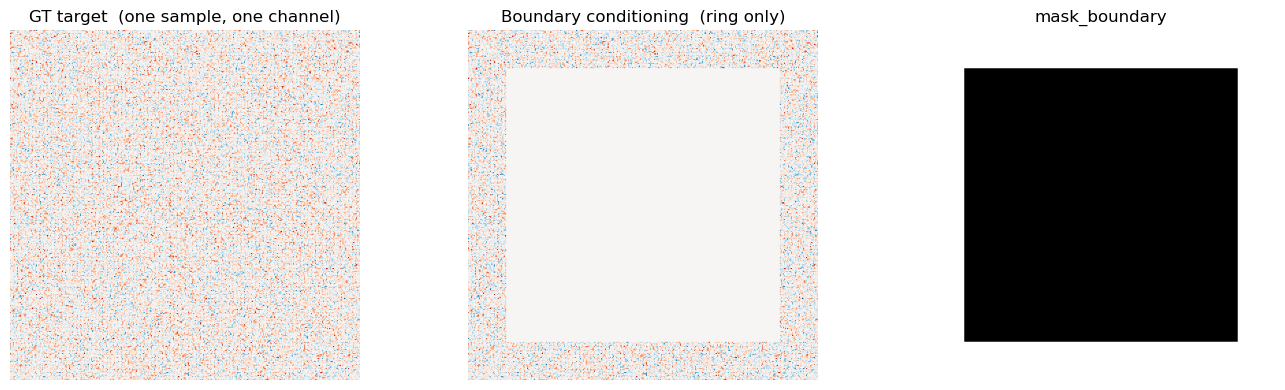

In [7]:
def extract_boundary_batch(tgt: torch.Tensor,
                           mask: torch.Tensor) -> torch.Tensor:
    """Extract boundary ring from a batch of clean GT targets.

    Args:
        tgt  : (B, C, H, W)
        mask : (H, W) — 1 in ring, 0 in centre
    Returns:
        boundary : (B, C, H, W) — GT values in ring, 0 elsewhere
    """
    # Expand mask to (1, 1, H, W) for broadcasting
    m = mask.to(tgt.device).unsqueeze(0).unsqueeze(0)
    boundary = torch.nan_to_num(tgt) * m
    return boundary


# ── Verify: centre of boundary is zero ───────────────────────────────────────
B = 4
tgt_dummy = torch.randn(B, C_OUT, PATCH_H, PATCH_W)
bound_dummy = extract_boundary_batch(tgt_dummy, mask_boundary)

centre_vals = bound_dummy[:, :, BORDER_H:-BORDER_H, BORDER_W:-BORDER_W]
ring_vals   = bound_dummy[:, :,  :BORDER_H, :]

print(f"Centre max absolute value : {centre_vals.abs().max():.6f}  (must be 0)")
print(f"Ring mean absolute value  : {ring_vals.abs().mean():.4f}   (should be > 0)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(tgt_dummy[0, 0].numpy(), cmap="RdBu_r")
axes[0].set_title("GT target  (one sample, one channel)")
axes[1].imshow(bound_dummy[0, 0].numpy(), cmap="RdBu_r")
axes[1].set_title("Boundary conditioning  (ring only)")
axes[2].imshow(mask_boundary.numpy(), cmap="gray")
axes[2].set_title("mask_boundary")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 6. Sequential Patch Inference with Boundary Propagation

### Strategy

At inference time the standard pipeline passes a **batch of patches** to `ConsistencyUNetSolver.forward(batch)`.  
When `add_bounds=True` we break this into a **one-by-one sequential loop**:

```
for each patch in raster order (row-major: top→bottom, left→right):
    boundary, mask_bound = build_boundary_conditioning(cache, iy, ix, ...)
    pred = model(patch, boundaries=boundary, mask_bound=mask_bound)
    cache[(iy, ix)] = pred
```

### Where to put it

Option A — **inside `ConsistencyUNetSolver.forward`**: receives the full batch + spatial positions, loops internally.  
Option B — **inside `Lit4dVarNet_CROSCIM_Consistency.test_step`**: the Lightning module drives the loop.

**Recommendation: Option A** (cleaner, self-contained, no Lightning changes).  
The solver receives `batch.yc`, `batch.xc` to determine `(iy, ix)` ordering.

### Pseudocode for `ConsistencyUNetSolver.forward` (add_bounds branch)

```python
if self.add_bounds:
    # Derive patch grid positions from batch coordinates
    # batch.input:  (B, C_in, H, W)
    # batch.yc:     (B, H)    — y coordinate of each pixel
    # batch.xc:     (B, W)    — x coordinate of each pixel
    order = raster_order(batch)          # list of batch indices sorted (iy, ix)
    cache = {}
    results = torch.empty_like(noise_init)

    for b_idx, (iy, ix) in order:
        y_b = batch.input[[b_idx]]       # (1, C_in, H, W)
        bound, mbound = build_boundary_conditioning(cache, iy, ix, ...)
        pred = self._sample_one(y_b, bound.to(device), mbound.to(device))
        cache[(iy, ix)] = pred[0]        # (C_out, H, W)
        results[b_idx]  = pred[0]
    return results
```

### Raster order derivation from coordinates

In [8]:
def raster_order(yc_batch: torch.Tensor,
                 xc_batch: torch.Tensor) -> list:
    """Return batch indices sorted in raster order (top→bottom, left→right).

    Args:
        yc_batch : (B, H) — y-coordinate of each row pixel in the patch
        xc_batch : (B, W) — x-coordinate of each col pixel in the patch
    Returns:
        List of (batch_idx, iy, ix) sorted by (iy, ix).
        iy / ix are integer grid indices (not coordinates).
    """
    # Use the top-left corner coordinate to identify the patch position
    y0 = yc_batch[:, 0].cpu().numpy()   # (B,) first row y-coord
    x0 = xc_batch[:, 0].cpu().numpy()   # (B,) first col x-coord

    # Map coordinates to grid indices
    unique_y = np.sort(np.unique(y0))[::-1]   # descending (north → south)
    unique_x = np.sort(np.unique(x0))         # ascending  (west  → east)

    y_to_iy = {float(y): i for i, y in enumerate(unique_y)}
    x_to_ix = {float(x): i for i, x in enumerate(unique_x)}

    items = [(b, y_to_iy[float(y0[b])], x_to_ix[float(x0[b])])
             for b in range(len(y0))]
    items.sort(key=lambda t: (t[1], t[2]))   # row-major
    return items


# ── Simulate a 3×4 patch grid ─────────────────────────────────────────────────
np.random.seed(0)
B_test = 12
# Fake top-left yc / xc coordinates for a 3×4 grid
ys = np.array([200, 0, -200] * 4)                # 3 rows
xs = np.array([-300, -100, 100, 300] * 3)[:B_test] # 4 cols
yc_fake = torch.tensor(ys[:B_test]).unsqueeze(1).expand(-1, PATCH_H).float()
xc_fake = torch.tensor(xs[:B_test]).unsqueeze(1).expand(-1, PATCH_W).float()

order = raster_order(yc_fake, xc_fake)
print("Raster order (batch_idx, iy, ix):")
for b, iy, ix in order:
    print(f"  b={b:2d}  (iy={iy}, ix={ix})")

Raster order (batch_idx, iy, ix):
  b= 0  (iy=0, ix=0)
  b= 9  (iy=0, ix=1)
  b= 6  (iy=0, ix=2)
  b= 3  (iy=0, ix=3)
  b= 4  (iy=1, ix=0)
  b= 1  (iy=1, ix=1)
  b=10  (iy=1, ix=2)
  b= 7  (iy=1, ix=3)
  b= 8  (iy=2, ix=0)
  b= 5  (iy=2, ix=1)
  b= 2  (iy=2, ix=2)
  b=11  (iy=2, ix=3)


---
## 7. Visualization: Patch Discontinuities Before/After

We simulate a full domain reconstruction with and without boundary conditioning and measure seam discontinuities using the gradient norm along patch borders.

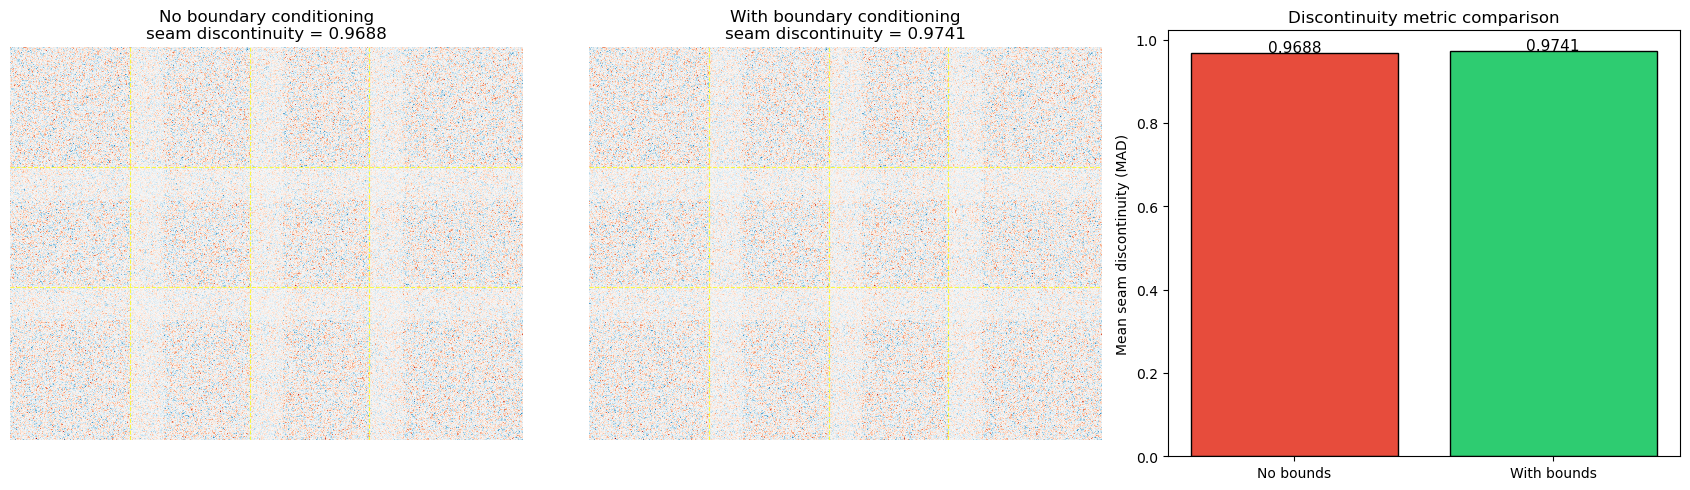


Improvement: -0.5 % reduction in seam discontinuity


In [10]:
def simulate_reconstruction(n_rows=3, n_cols=4,
                             patch_h=PATCH_H, patch_w=PATCH_W,
                             stride_h=STRIDE_H, stride_w=STRIDE_W,
                             add_bounds=False,
                             border_h=BORDER_H, border_w=BORDER_W,
                             seed=42):
    """Simulate independent patch predictions and stitch them into a domain field.

    Without add_bounds: each patch is independent Gaussian noise → strong seams.
    With    add_bounds: boundary of a patch is forced to match its left/top
                        neighbour → smoother seams (toy simulation).
    """
    torch.manual_seed(seed)
    domain_h = stride_h * n_rows + (patch_h - stride_h)
    domain_w = stride_w * n_cols + (patch_w - stride_w)

    result = torch.zeros(domain_h, domain_w)
    count  = torch.zeros(domain_h, domain_w)
    cache: Dict[Tuple[int,int], torch.Tensor] = {}
    mask  = make_boundary_mask(patch_h, patch_w, border_h, border_w)

    for iy in range(n_rows):
        for ix in range(n_cols):
            pred = torch.randn(patch_h, patch_w)   # independent prediction

            if add_bounds:
                # Force boundary to match neighbours (toy: blend, not a real model)
                # cache stores (C=1, H, W) tensors as expected by build_boundary_conditioning
                bound, mbound = build_boundary_conditioning(
                    cache,   # already (C=1, H, W) format
                    iy, ix, mask, border_h, border_w
                )
                bound  = bound[0]    # (H, W)
                mbound = mbound[0]   # (H, W)
                # Replace predicted ring with neighbour ring where available
                pred = pred * (1. - mbound) + bound * mbound

            cache[(iy, ix)] = pred.unsqueeze(0)   # store as (C=1, H, W)

            # Place patch into domain (simple average for overlap)
            y0, x0 = iy * stride_h, ix * stride_w
            result[y0 : y0 + patch_h, x0 : x0 + patch_w] += pred
            count [y0 : y0 + patch_h, x0 : x0 + patch_w] += 1.

    result /= count.clamp(min=1.)
    return result


def seam_discontinuity(field: torch.Tensor,
                       stride_h: int, stride_w: int) -> float:
    """Mean absolute gradient across patch seams."""
    H, W = field.shape
    seam_vals = []
    for sy in range(stride_h, H - 1, stride_h):
        seam_vals.append((field[sy] - field[sy - 1]).abs().mean().item())
    for sx in range(stride_w, W - 1, stride_w):
        seam_vals.append((field[:, sx] - field[:, sx - 1]).abs().mean().item())
    return float(np.mean(seam_vals)) if seam_vals else 0.


# ── Run simulation ────────────────────────────────────────────────────────────
field_no_bound = simulate_reconstruction(add_bounds=False)
field_bound    = simulate_reconstruction(add_bounds=True)

disc_no = seam_discontinuity(field_no_bound, STRIDE_H, STRIDE_W)
disc_b  = seam_discontinuity(field_bound,    STRIDE_H, STRIDE_W)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
vmin, vmax = -2.5, 2.5

im0 = axes[0].imshow(field_no_bound, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[0].set_title(f"No boundary conditioning\nseam discontinuity = {disc_no:.4f}")
axes[0].axis("off")

im1 = axes[1].imshow(field_bound, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[1].set_title(f"With boundary conditioning\nseam discontinuity = {disc_b:.4f}")
axes[1].axis("off")

# Draw patch seams
for ax in axes[:2]:
    for r in range(1, 3):
        ax.axhline(r * STRIDE_H, color="yellow", lw=0.8, ls="--", alpha=0.7)
    for c in range(1, 4):
        ax.axvline(c * STRIDE_W, color="yellow", lw=0.8, ls="--", alpha=0.7)

# Discontinuity bar chart
axes[2].bar(["No bounds", "With bounds"], [disc_no, disc_b],
            color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[2].set_ylabel("Mean seam discontinuity (MAD)")
axes[2].set_title("Discontinuity metric comparison")
for i, v in enumerate([disc_no, disc_b]):
    axes[2].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()
print(f"\nImprovement: {100*(disc_no - disc_b)/disc_no:.1f} % reduction in seam discontinuity")


---
## 8. Summary — Implementation Checklist

### Files to modify

| # | File | What to add |
|---|---|---|
| 1 | `consistency_solver.py` | `ConsistencyUNetConfig`: add `add_bounds: bool = False`, `n_bound_channels: int = None` |
| 2 | `consistency_solver.py` | `ConsistencyUNet.__init__`: extend `total_input_channels` by `2 * n_bound` when `add_bounds` |
| 3 | `consistency_solver.py` | `ConsistencyUNet.forward`: accept `boundaries=None`, `mask_bound=None`; cat them into `inp` |
| 4 | `consistency_solver.py` | `ConsistencyUNetSolver.__init__`: add `add_bounds`, `border_h`, `border_w`; build `mask_boundary` |
| 5 | `consistency_solver.py` | `ConsistencyUNetSolver.forward`: sequential loop + `build_boundary_conditioning` when `add_bounds` |
| 6 | `models_consistency.py` | `Lit4dVarNet_CROSCIM_Consistency.__init__`: accept `add_bounds`, `border_h`, `border_w`; register `mask_boundary` as buffer |
| 7 | `models_consistency.py` | `base_step` (train): call `extract_boundary_batch` and pass `boundaries`/`mask_bound` kwargs |

### YAML changes

```yaml
# In the model solver config (per resolution):
solver_x10:
  _target_: contrib.CROSCIM.consistency_solver.ConsistencyUNetSolver
  add_bounds: true
  border_h: 28       # (patch_h - stride_h) // 2
  border_w: 28       # (patch_w - stride_w) // 2
  ...

# In the model config:
model:
  add_bounds: true
```

### Notes on multi-GPU inference

- Sequential boundary inference **must run on a single process** because `(iy, ix-1)` must be computed before `(iy, ix)`
- In the existing `_finalize_res` hook, all patches are already gathered to rank 0 before reconstruction → the sequential solver loop runs **entirely on rank 0**, no extra changes needed
- On rank ≥ 1, `test_step` still runs the standard (non-sequential) forward pass for metrics logging; only the reconstruction in `_finalize_res` uses the boundary-aware sequential path

### Complexity

- **No new hyperparameters** beyond `add_bounds`, `border_h`, `border_w`
- **Inference is serial** per patch (no batch parallelism when `add_bounds=True`) — acceptable because test is already the slow path
- **Training is fully batched** (boundary extracted from GT, no sequential dependency)